In [2]:
!pip install pyarrow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_parquet('eco2mix-regional-cons-def.parquet')

In [3]:
# découverte du dataset
display(df.head())
display(df.tail())

,code_insee_region,libelle_region,nature,date,heure,date_heure,consommation,thermique,nucleaire,eolien,...,tch_nucleaire,tco_eolien,tch_eolien,tco_solaire,tch_solaire,tco_hydraulique,tch_hydraulique,tco_bioenergies,tch_bioenergies,column_30
0,76,Occitanie,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,53,Bretagne,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,27,Bourgogne-Franche-Comté,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,84,Auvergne-Rhône-Alpes,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,32,Hauts-de-France,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


,code_insee_region,libelle_region,nature,date,heure,date_heure,consommation,thermique,nucleaire,eolien,...,tch_nucleaire,tco_eolien,tch_eolien,tco_solaire,tch_solaire,tco_hydraulique,tch_hydraulique,tco_bioenergies,tch_bioenergies,column_30
2524603,84,Auvergne-Rhône-Alpes,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,9488.0,112.0,11457.0,115,...,84.43,1.21,15.71,0.00,0.00,26.36,21.86,1.19,56.22,None
2524604,44,Grand Est,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5521.0,173.0,10713.0,1042,...,99.01,18.87,21.07,0.00,0.00,12.97,31.09,2.92,64.66,None
2524605,75,Nouvelle-Aquitaine,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,6828.0,100.0,5061.0,303,...,76.33,4.44,14.93,0.00,0.00,6.81,20.74,2.65,50.70,None
2524606,93,Provence-Alpes-Côte d'Azur,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5908.0,685.0,0.0,0,...,NaN,0.00,0.00,0.02,0.04,9.31,17.04,2.22,40.43,None
2524607,32,Hauts-de-France,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5818.0,199.0,4558.0,4953,...,83.48,85.13,78.22,0.00,0.00,0.03,50.00,2.11,62.44,None


In [4]:
# découverte du dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524608 entries, 0 to 2524607
Data columns (total 32 columns):
 #   Column               Dtype                        
---  ------               -----                        
 0   code_insee_region    object                       
 1   libelle_region       object                       
 2   nature               object                       
 3   date                 object                       
 4   heure                object                       
 5   date_heure           datetime64[ms, Europe/Berlin]
 6   consommation         float64                      
 7   thermique            float64                      
 8   nucleaire            float64                      
 9   eolien               object                       
 10  solaire              float64                      
 11  hydraulique          float64                      
 12  pompage              float64                      
 13  bioenergies          float64              

In [5]:
#on recherche s'il y des valeurs manquantes (NaN)
print(df.isna().sum())

code_insee_region            0
libelle_region               0
nature                       0
date                         0
heure                        0
date_heure                   0
consommation                12
thermique                   12
nucleaire               701287
eolien                       0
solaire                     12
hydraulique                 12
pompage                 736327
bioenergies                 12
ech_physiques               12
stockage_batterie      1683084
destockage_batterie    1683084
eolien_terrestre       1683084
eolien_offshore        1683084
tco_thermique          1472256
tch_thermique          1472256
tco_nucleaire          1560096
tch_nucleaire          1910736
tco_eolien             1472256
tch_eolien             1472256
tco_solaire            1472256
tch_solaire            1472256
tco_hydraulique        1472256
tch_hydraulique        1472256
tco_bioenergies        1472256
tch_bioenergies        1472256
column_30              2524608
dtype: i

In [6]:
#on a remarqué qu'il y avait de nombreuses valeurs manquantes, on affiche les proportions par colonne
print((df.isna().mean().round(2)))

code_insee_region      0.00
libelle_region         0.00
nature                 0.00
date                   0.00
heure                  0.00
date_heure             0.00
consommation           0.00
thermique              0.00
nucleaire              0.28
eolien                 0.00
solaire                0.00
hydraulique            0.00
pompage                0.29
bioenergies            0.00
ech_physiques          0.00
stockage_batterie      0.67
destockage_batterie    0.67
eolien_terrestre       0.67
eolien_offshore        0.67
tco_thermique          0.58
tch_thermique          0.58
tco_nucleaire          0.62
tch_nucleaire          0.76
tco_eolien             0.58
tch_eolien             0.58
tco_solaire            0.58
tch_solaire            0.58
tco_hydraulique        0.58
tch_hydraulique        0.58
tco_bioenergies        0.58
tch_bioenergies        0.58
column_30              1.00
dtype: float64


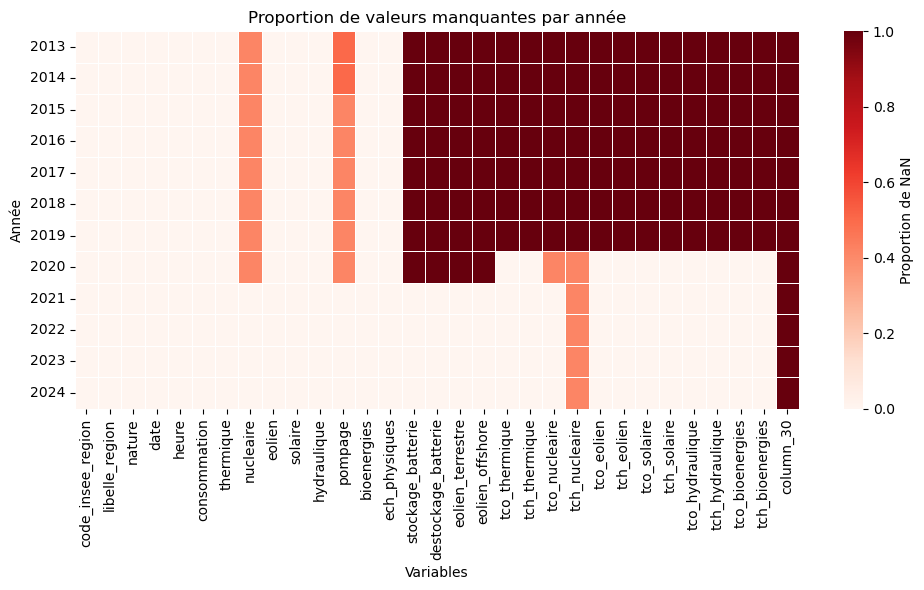

In [7]:
# Graphique Heatmap valeurs manquantes

plt.figure(figsize=(10,6))

yearly_nan = (df.set_index("date_heure").isna().resample("YE").mean())
yearly_nan.index = yearly_nan.index.year

sns.heatmap(yearly_nan,cmap="Reds",cbar_kws={'label': 'Proportion de NaN'},linewidths=0.5)

plt.title("Proportion de valeurs manquantes par année")
plt.xlabel("Variables")
plt.ylabel("Année")

plt.yticks(rotation=0)  
plt.xticks(rotation=90)  

plt.tight_layout()
plt.show()

In [8]:
# nettoyage du dataset - 1
#conversion des variables date et heure en type datetime :
df = pd.read_parquet("eco2mix-regional-cons-def.parquet")
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
df["heure"] = pd.to_datetime(df["heure"], format="%H:%M")

In [9]:
# nettoyage du dataset - 2
#remplacement des NaN par 0 dans colonnes nucleaire et pompage
df['nucleaire'] = df['nucleaire'].fillna(0)
df['pompage'] = df['pompage'].fillna(0)

# vérification :
print(df.isna().sum())

code_insee_region            0
libelle_region               0
nature                       0
date                         0
heure                        0
date_heure                   0
consommation                12
thermique                   12
nucleaire                    0
eolien                       0
solaire                     12
hydraulique                 12
pompage                      0
bioenergies                 12
ech_physiques               12
stockage_batterie      1683084
destockage_batterie    1683084
eolien_terrestre       1683084
eolien_offshore        1683084
tco_thermique          1472256
tch_thermique          1472256
tco_nucleaire          1560096
tch_nucleaire          1910736
tco_eolien             1472256
tch_eolien             1472256
tco_solaire            1472256
tch_solaire            1472256
tco_hydraulique        1472256
tch_hydraulique        1472256
tco_bioenergies        1472256
tch_bioenergies        1472256
column_30              2524608
dtype: i

In [10]:
# nettoyage du dataset - 3
#traitement de la colonne eolien, suppression des lignes avec ND
df = df[df['eolien'] != "ND"] # nous supprimons les 12 lignes qui comporte ND dans la colonne
df['eolien'] = df['eolien'].replace('-', 0) #Il y a une ligne qui pose problème pour la conversion en float: elle indique "-" au lieu de 0 (remplacement de la valeur)
df['eolien'] = df['eolien'].astype(float)

In [11]:
# nettoyage du dataset - 4
#colonnes à supprimer, car ne seront pas exploitées
colonnes_a_supprimer = [
    "nature",
    "stockage_batterie",
    "destockage_batterie",
    "eolien_terrestre",
    "eolien_offshore",
    "column_30"
]
df = df.drop(columns=colonnes_a_supprimer, errors='ignore')

In [12]:
# nettoyage du dataset - 5
#Affichage Doublons sur région et date heure :
cle = ["code_insee_region", "date_heure"]
nb_doublons_cle = df.duplicated(subset=cle).sum()
print("Doublons sur la clé (région + date_heure):", nb_doublons_cle)

#Affichage Doublons sur Nombre de lignes :
nb_doublons_lignes = df.duplicated().sum()
print("Doublons exacts (lignes identiques):", nb_doublons_lignes)

#Traitement des doublons :
#Supprimer les doublons sur clé:
df = df.drop_duplicates(subset=["code_insee_region","date_heure"], keep="first")

Doublons sur la clé (région + date_heure): 288
Doublons exacts (lignes identiques): 0


In [13]:
# nettoyage du dataset - 6
#verification Type et colonnes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2524308 entries, 12 to 2524607
Data columns (total 26 columns):
 #   Column             Dtype                        
---  ------             -----                        
 0   code_insee_region  object                       
 1   libelle_region     object                       
 2   date               datetime64[ns]               
 3   heure              datetime64[ns]               
 4   date_heure         datetime64[ms, Europe/Berlin]
 5   consommation       float64                      
 6   thermique          float64                      
 7   nucleaire          float64                      
 8   eolien             float64                      
 9   solaire            float64                      
 10  hydraulique        float64                      
 11  pompage            float64                      
 12  bioenergies        float64                      
 13  ech_physiques      float64                      
 14  tco_thermique      flo

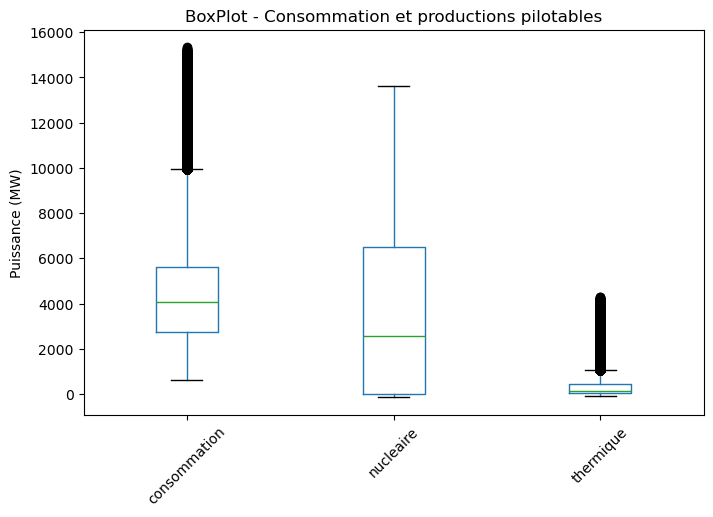

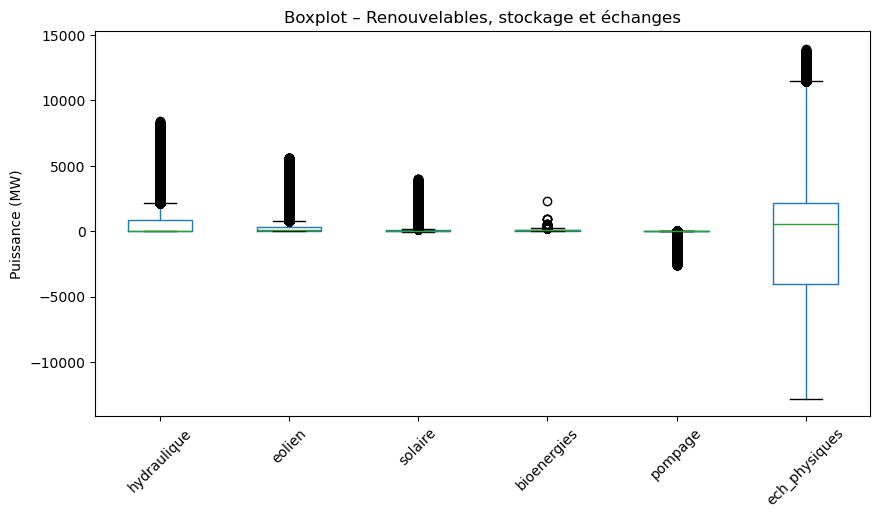

In [14]:
# visualisation de la distribution des variables de production et consommation 
#Boxplot 1/2

plt.style.use("default")

groupe1 = [
    "consommation",
    "nucleaire",
    "thermique"
]

plt.figure(figsize=(8,5))
df[groupe1].boxplot()

plt.title("BoxPlot - Consommation et productions pilotables")
plt.ylabel("Puissance (MW)")
plt.xticks(rotation=45)
plt.grid(False)

plt.show()

#Boxplot 2/2
groupe2 = [
    "hydraulique",
    "eolien",
    "solaire",
    "bioenergies",
    "pompage",
    "ech_physiques"
]

plt.figure(figsize=(10,5))
df[groupe2].boxplot()

plt.title("Boxplot – Renouvelables, stockage et échanges")
plt.ylabel("Puissance (MW)")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

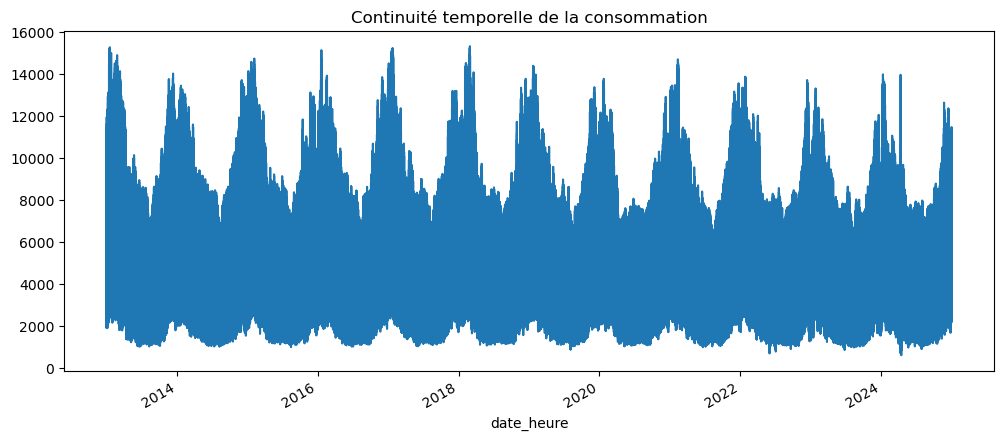

In [15]:
# visualisation de l'évolution de la consommation dans le temps
# Continuité temporelle consommation :
df["date_heure"] = df["date_heure"]
df.set_index("date_heure")["consommation"].plot(figsize=(12,5))
plt.title("Continuité temporelle de la consommation")
plt.show()

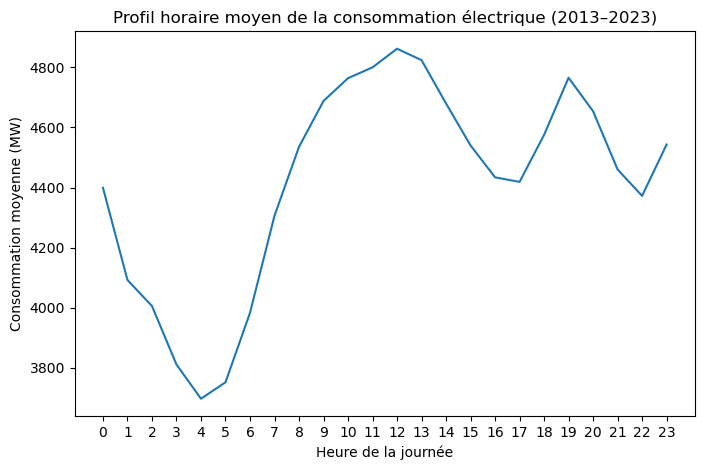

In [16]:
# Profil moyen de la consommation :
plt.style.use("default")
df["heure"] = df["date_heure"].dt.hour
plt.figure(figsize=(8,5))
df.groupby("heure")["consommation"].mean().plot()
plt.title("Profil horaire moyen de la consommation électrique (2013–2023)")
plt.xlabel("Heure de la journée")
plt.ylabel("Consommation moyenne (MW)")
plt.xticks(range(0,24))
plt.grid(False)  # supprime les lignes horizontales et verticales
plt.show()

Text(0.5, 1.0, 'Corrélation Production / Consommation')

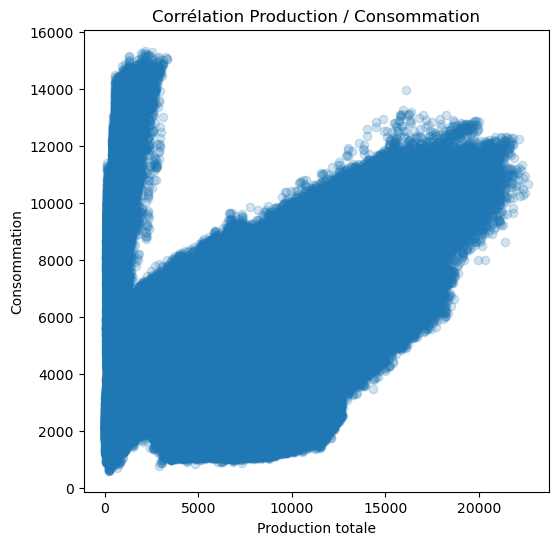

In [17]:
# visualisation de la corrélation entre Production / Consommation (Graphique Nuage de point)
#création d'une colonne production totale :
df["production_totale"] = (df["thermique"] +df["nucleaire"] +df["eolien"] +df["solaire"] + df["hydraulique"]+ df["bioenergies"])
#création du graphique :
plt.figure(figsize=(6,6))
plt.scatter(df["production_totale"], df["consommation"], alpha=0.2)
plt.xlabel("Production totale")
plt.ylabel("Consommation")
plt.title("Corrélation Production / Consommation")

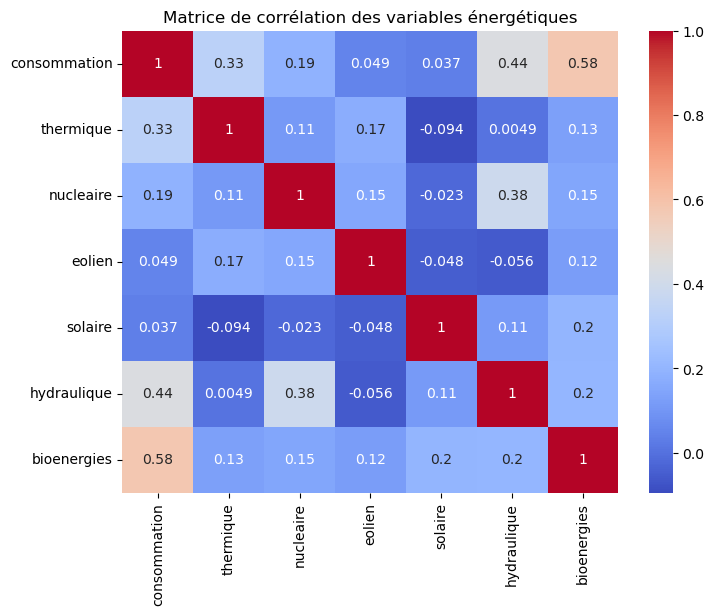

In [19]:
# Matrice de corrélation des variables énergétiques
cols = ["consommation", "thermique", "nucleaire", "eolien", "solaire", "hydraulique","bioenergies"]
plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation des variables énergétiques")
plt.show()

In [20]:
#rajout colonnes TCO recalculé
df['tco_thermique_recalc'] = (df['thermique']/df['consommation'])*100
df['tco_nucleaire_recalc'] = (df['nucleaire']/df['consommation'])*100
df['tco_eolien_recalc'] = (df['eolien']/df['consommation'])*100
df['tco_solaire_recalc'] = (df['solaire']/df['consommation'])*100
df['tco_hydraulique_recalc'] = (df['hydraulique']/df['consommation'])*100
df['tco_bioenergies_recalc'] = (df['bioenergies']/df['consommation'])*100

#verif
# Filtrer les lignes où la colonne 'date' est antérieure à 2019
df_apres_2020 = df[df['date'].dt.year > 2020]
# Calculer la somme des TCO fournis vs TCO recalculés  
somme_tco_thermique = df_apres_2020['tco_thermique'].sum()
somme_tco_thermique_recalc = df_apres_2020['tco_thermique_recalc'].sum()
# Afficher le résultat
print(somme_tco_thermique)
print(somme_tco_thermique_recalc)

# Calculer la somme des TCO fournis vs TCO recalculés  
somme_tco_nucleaire = df_apres_2020['tco_nucleaire'].sum()
somme_tco_nucleaire_recalc = df_apres_2020['tco_nucleaire_recalc'].sum()
# Afficher le résultat
print(somme_tco_nucleaire)
print(somme_tco_nucleaire_recalc)


# Calculer la somme des TCO fournis vs TCO recalculés  
somme_tco_eolien = df_apres_2020['tco_eolien'].sum()
somme_tco_eolien_recalc = df_apres_2020['tco_eolien_recalc'].sum()
# Afficher le résultat
print(somme_tco_eolien)
print(somme_tco_eolien_recalc)

# Calculer la somme des TCO fournis vs TCO recalculés  
somme_tco_solaire = df_apres_2020['tco_solaire'].sum()
somme_tco_solaire_recalc = df_apres_2020['tco_solaire_recalc'].sum()
# Afficher le résultat
print(somme_tco_solaire)
print(somme_tco_solaire_recalc)

# Calculer la somme des TCO fournis vs TCO recalculés  
somme_tco_hydraulique = df_apres_2020['tco_hydraulique'].sum()
somme_tco_hydraulique_recalc = df_apres_2020['tco_hydraulique_recalc'].sum()
# Afficher le résultat
print(somme_tco_hydraulique)
print(somme_tco_hydraulique_recalc)

# Calculer la somme des TCO fournis vs TCO recalculés  
somme_tco_bioenergies = df_apres_2020['tco_bioenergies'].sum()
somme_tco_bioenergies_recalc = df_apres_2020['tco_bioenergies_recalc'].sum()
# Afficher le résultat
print(somme_tco_bioenergies)
print(somme_tco_bioenergies_recalc)

5978613.2
5978612.876488937
72549096.33
72549095.46228868
9172729.850000001
9172730.527083986
3989823.46
3989815.725450879
9334512.280000001
9334504.972880099
2112479.3499999996
2112475.5604107403


In [21]:
#export du dataframe en csv avec decimal , vs . :
df.to_csv(r'C:\Users\kadi\Desktop\Liora\projet_filrouge\electricite.csv',index=False,decimal= ',')